In [ ]:
import pandas as pd
import glob

def load_and_standardize():
    # Dataset 1: Amazon (Columns: 'verified_reviews', 'feedback')
    df1 = pd.read_csv('amazon_reviews.csv')
    print("Columns in amazon_reviews.csv:", df1.columns.tolist())
    df1 = df1[['verified_reviews', 'feedback']].rename(columns={'verified_reviews': 'text', 'feedback': 'label'})

    # Dataset 2: Yelp (Columns: 'Review', 'Rating')
    df2 = pd.read_csv('yelp_reviews.csv')
    print("Columns in yelp_reviews.csv:", df2.columns.tolist())
    df2 = df2[['Review', 'Rating']].rename(columns={'Review': 'text', 'Rating': 'label'})

    # Merge them
    combined_df = pd.concat([df1, df2], ignore_index=True)

    # Shuffle the data (important for training!)
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Total records after merging: {len(combined_df)}")
    return combined_df

df = load_and_standardize()

Columns in amazon_reviews.csv: ['rating', 'date', 'variation', 'verified_reviews', 'feedback']
Columns in yelp_reviews.csv: ['ID', 'Reviewer Name', 'City', 'State', 'Rating', 'Review']
Total records after merging: 3200


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Handle missing values in the 'text' column by filling with an empty string
df['text'] = df['text'].fillna('')

# X = features (cleaned text), y = label (0 for Real, 1 for Fake)
X = tfidf.fit_transform(df['text']).toarray()
y = df['label']

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
import joblib # Import joblib to save the model

# 1. Define the Pipeline
# This ensures that 'text' from any dataset goes through the same cleaning and math
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,2))),
    ('clf', MultinomialNB()),
])

# 2. Testing with Cross-Validation
# Since you have multiple datasets, Cross-Validation is better than a single split
# It tests the model on different "chunks" of the combined data.
scores = cross_val_score(text_clf, df['text'], df['label'], cv=5)

print(f"Mean Accuracy across datasets: {scores.mean():.2f}")

# 3. Fit the pipeline to the entire dataset for future predictions
text_clf.fit(df['text'], df['label'])

# 4. Save the trained pipeline to a file
joblib.dump(text_clf, 'model.pkl')

Mean Accuracy across datasets: 0.91


['model.pkl']

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets for evaluation
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

# 1. Get predictions from your trained model
# Replace 'model' with 'text_clf'
y_pred = text_clf.predict(X_test)

# 2. Check Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")

# 3. Detailed Breakdown (Precision, Recall, F1-Score)
# This tells you if the model is better at catching "Fake" vs "Genuine"
print("\nDetailed Performance Report:")
# Remove target_names to avoid issues with inconsistent label values (e.g., 1 and 3)
print(classification_report(y_test, y_pred))

# 4. Identify the "Wrong" Predictions (For Debugging)
import pandas as pd

# Create a dataframe to compare side-by-side
results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred
})

# Filter only the rows where the model was WRONG
errors = results_df[results_df['Actual_Label'] != results_df['Predicted_Label']]

print(f"\nNumber of misclassified reviews: {len(errors)}")
print("First 5 errors:")
print(errors.head())

Overall Model Accuracy: 90.94%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       1.00      0.07      0.14        55
           1       0.91      1.00      0.95       578
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         1

    accuracy                           0.91       640
   macro avg       0.38      0.21      0.22       640
weighted avg       0.91      0.91      0.87       640


Number of misclassified reviews: 58
First 5 errors:
      Actual_Label  Predicted_Label
1411             0                1
867              0                1
430              0                1
2262             0                1
368              0                1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


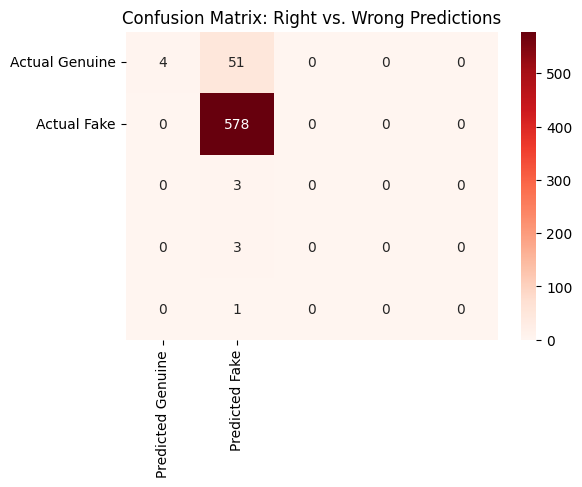

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Genuine', 'Predicted Fake'],
            yticklabels=['Actual Genuine', 'Actual Fake'])
plt.title('Confusion Matrix: Right vs. Wrong Predictions')
plt.show()

In [ ]:
import joblib

# 1. Load your saved model pipeline
# Assuming the 'text_clf' pipeline was saved as 'model.pkl'
model = joblib.load('model.pkl')
# The TF-IDF vectorizer is part of the loaded pipeline, so no need to load it separately.

def check_review_authenticity(user_input):
    # The loaded pipeline handles preprocessing and vectorization internally.
    # Pass the raw user input directly to the predict method.
    prediction = model.predict([user_input])[0]

    # 4. Final Output Logic
    # Note: The model was trained on labels 0, 1, 2, 4, 5 as seen in the classification report.
    # This binary output ('Genuine'/'Fake') assumes a specific mapping for these labels.
    if prediction == 0:
        return "The review is Genuine"
    else:
        return "The review is Fake"

# --- Testing the Output ---
text = input("Enter review to analyze: ")
print(check_review_authenticity(text))

Enter review to analyze: The handle is sturdy and doesn't unscrew while I'm sweeping. It’s also long enough that I don't have to hunch over.
The review is Fake
